In [33]:
import pandas as pd

csv_path = "combined_apr_sep_2025_area1.csv"

# Read CSV into a DataFrame
combined_df = pd.read_csv(csv_path)

combined_df.head()

,time,eu_1,eu_2,eu_3,eu_4,eu_5,eu_6,eu_7,eu_8,eu_9,...,eu_15,eu_16,eu_17,eu_18,eu_19,eu_20,eu_21,eu_22,eu_23,eu_24
0,2025-04-18 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-04-18 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-04-18 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-04-18 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-04-18 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
import numpy as np

# Work only with the columns we care about and ensure proper time dtype
pair_df = combined_df[["time", "eu_8", "eu_20"]].copy()
pair_df["time"] = pd.to_datetime(pair_df["time"])

# Keep only rows where both eu_8 and eu_20 are non-zero
non_zero_mask = (pair_df["eu_8"] != 0) & (pair_df["eu_20"] != 0)
clean_df = pair_df[non_zero_mask].copy()

# Compute power difference (eu_20 - eu_8) and its absolute value
clean_df["diff"] = clean_df["eu_20"] - clean_df["eu_8"]
clean_df["abs_diff"] = clean_df["diff"].abs()

# Identify "suddenly big" differences via z-score outliers
if not clean_df.empty:
    mean_diff = clean_df["abs_diff"].mean()
    std_diff = clean_df["abs_diff"].std(ddof=0)

    # Avoid division by zero if std is 0
    if std_diff == 0:
        big_jumps = clean_df.iloc[0:0]  # empty
    else:
        z_scores = (clean_df["abs_diff"] - mean_diff) / std_diff
        big_jumps = clean_df[z_scores >= 1.5].copy()  # z >= 3 as "suddenly big"

    display("Total non-zero rows considered:", len(clean_df))
    display("Number of suddenly-big differences:", len(big_jumps))
    big_jumps.sort_values("time", inplace=True)
    big_jumps.head(20)
else:
    print("No non-zero readings for eu_8 and eu_20 to compare.")

'Total non-zero rows considered:'

19972

'Number of suddenly-big differences:'

2243

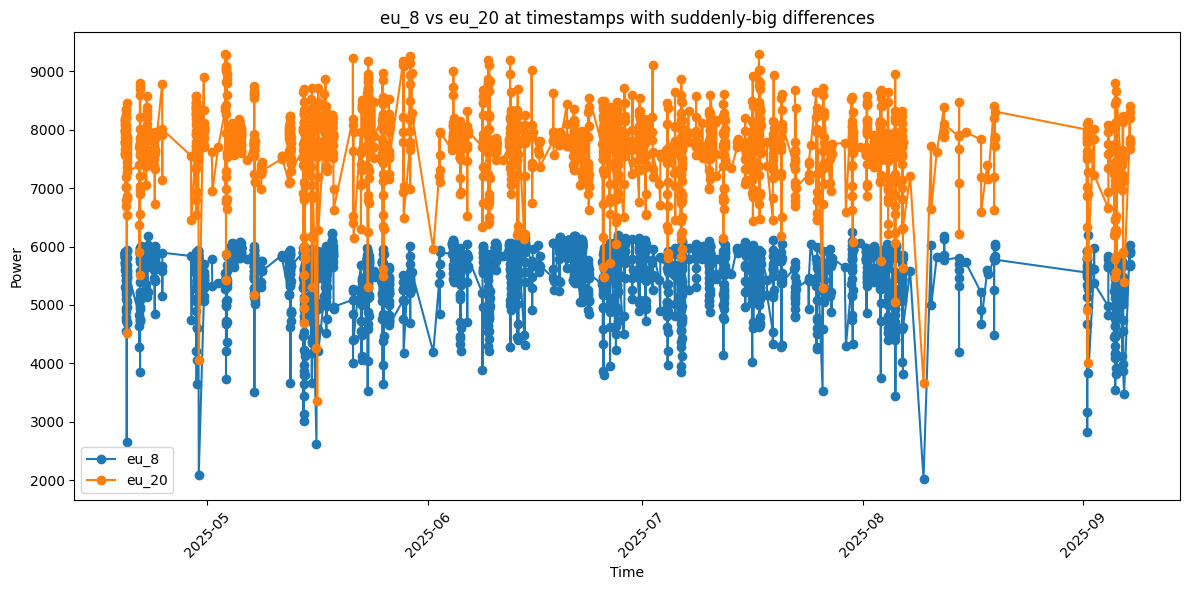

In [35]:
import matplotlib.pyplot as plt

# Ensure we have the timestamps of suddenly-big differences
if 'big_jumps' not in globals() or big_jumps.empty:
    raise RuntimeError("big_jumps is empty or not defined. Run the previous analysis cell first.")

# Take only those timestamps and corresponding eu_8 / eu_20 values
plot_df = combined_df.copy()
plot_df["time"] = pd.to_datetime(plot_df["time"])
plot_df = plot_df[plot_df["time"].isin(big_jumps["time"])]
plot_df = plot_df.sort_values("time")

plt.figure(figsize=(12, 6))
plt.plot(plot_df["time"], plot_df["eu_8"], marker="o", label="eu_8")
plt.plot(plot_df["time"], plot_df["eu_20"], marker="o", label="eu_20")

plt.xlabel("Time")
plt.ylabel("Power")
plt.title("eu_8 vs eu_20 at timestamps with suddenly-big differences")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Compute ratios for non-suddenly-big timestamps

# Start from all data and drop timestamps that had suddenly-big eu_8 vs eu_20 differences
ratio_df = combined_df.copy()
ratio_df["time"] = pd.to_datetime(ratio_df["time"])

if "big_jumps" in globals() and not big_jumps.empty:
    ratio_df = ratio_df[~ratio_df["time"].isin(big_jumps["time"])]

# Drop any timestamps whose time falls between first_big_jump and last_big_jump
# for that specific day (if that day has big jumps recorded in per_day)
if "per_day" in globals():
    per_day_local = per_day.copy()
    per_day_local["date"] = per_day_local["date"].astype("datetime64[ns]")
    per_day_local["date"] = per_day_local["date"].dt.date

    ratio_df["date"] = ratio_df["time"].dt.date
    ratio_df = ratio_df.merge(per_day_local, how="left", on="date")

    # Keep rows that are either on days without big jumps (first/last are NaT)
    # or strictly before first_big_jump, or strictly after last_big_jump
    mask_ok = (
        ratio_df["first_big_jump"].isna()
        | ratio_df["last_big_jump"].isna()
        | (ratio_df["time"] < ratio_df["first_big_jump"])
        | (ratio_df["time"] > ratio_df["last_big_jump"])
    )
    ratio_df = ratio_df[mask_ok]

ratio_df = ratio_df.sort_values("time").reset_index(drop=True)

# Helper to compute ratios for a set of (numerator, denominator) pairs
from collections import OrderedDict

def compute_pair_ratios(df, pairs):
    results = OrderedDict()
    for num_col, den_col in pairs:
        pair_name = f"{num_col}_over_{den_col}"
        # Only keep rows where both panels are non-zero
        mask = (df[num_col] != 0) & (df[den_col] != 0)
        tmp = df.loc[mask, ["time", num_col, den_col]].copy()
        tmp[pair_name] = tmp[num_col] / tmp[den_col]
        results[pair_name] = tmp
    return results

# Define the three groups of ratios (exclude self-ratios like eu_5/eu_5 and eu_15/eu_15)
pairs_group1 = [(f"eu_{i}", "eu_5") for i in range(1, 9) if i != 5]  # eu_1..eu_4, eu_6..eu_8 over eu_5
pairs_group2 = [(f"eu_{i}", "eu_15") for i in range(9, 17) if i != 15]  # eu_9..eu_14, eu_16 over eu_15
pairs_group3 = [(f"eu_{i}", "eu_17") for i in range(18, 25)]  # eu_18..eu_24 over eu_17

ratios_group1 = compute_pair_ratios(ratio_df, pairs_group1)
ratios_group2 = compute_pair_ratios(ratio_df, pairs_group2)
ratios_group3 = compute_pair_ratios(ratio_df, pairs_group3)

# Example: show a few rows from each group
print("Group 1 (eu_1..eu_8 over eu_5):")
for name, df_pair in list(ratios_group1.items())[:3]:  # show first 3 as sample
    display(name, df_pair.head())

print("Group 2 (eu_9..eu_16 over eu_15):")
for name, df_pair in list(ratios_group2.items())[:3]:
    display(name, df_pair.head())

print("Group 3 (eu_18..eu_24 over eu_17):")
for name, df_pair in list(ratios_group3.items())[:3]:
    display(name, df_pair.head())

Group 1 (eu_1..eu_8 over eu_5):


'eu_1_over_eu_5'

,time,eu_1,eu_5,eu_1_over_eu_5
87,2025-04-18 07:15:00,16.9251,5.6292,3.006662
88,2025-04-18 07:20:00,104.9670,81.3092,1.290961
89,2025-04-18 07:25:00,140.7472,143.0682,0.983777
90,2025-04-18 07:30:00,63.7580,65.1618,0.978457
91,2025-04-18 07:35:00,96.5865,106.4574,0.907278


'eu_2_over_eu_5'

,time,eu_2,eu_5,eu_2_over_eu_5
87,2025-04-18 07:15:00,5.7000,5.6292,1.012577
88,2025-04-18 07:20:00,77.8362,81.3092,0.957287
89,2025-04-18 07:25:00,111.0491,143.0682,0.776197
90,2025-04-18 07:30:00,48.9600,65.1618,0.751360
91,2025-04-18 07:35:00,64.4270,106.4574,0.605190


...

,time,eu_18,eu_17,eu_18_over_eu_17
88,2025-04-18 07:20:00,118.1819,46.9976,2.514637
89,2025-04-18 07:25:00,170.4591,91.0868,1.871392
90,2025-04-18 07:30:00,81.1382,6.4731,12.534674
91,2025-04-18 07:35:00,127.2460,66.5090,1.913215
92,2025-04-18 07:40:00,128.1620,58.7691,2.180772


'eu_19_over_eu_17'

,time,eu_19,eu_17,eu_19_over_eu_17
88,2025-04-18 07:20:00,59.0300,46.9976,1.256022
89,2025-04-18 07:25:00,103.5680,91.0868,1.137025
90,2025-04-18 07:30:00,29.9275,6.4731,4.623364
91,2025-04-18 07:35:00,64.7320,66.5090,0.973282
92,2025-04-18 07:40:00,77.2608,58.7691,1.314650


'eu_20_over_eu_17'

,time,eu_20,eu_17,eu_20_over_eu_17
88,2025-04-18 07:20:00,76.0097,46.9976,1.617310
89,2025-04-18 07:25:00,97.5270,91.0868,1.070704
90,2025-04-18 07:30:00,41.9272,6.4731,6.477144
91,2025-04-18 07:35:00,65.6470,66.5090,0.987039
92,2025-04-18 07:40:00,78.4164,58.7691,1.334313


In [37]:
# Compute TOTAL power ratios: (sum of numerator) / (sum of denominator)
# using the same filtered timestamps (non-suddenly-big and both panels non-zero)

from collections import OrderedDict

# Reuse ratio_df (non-suddenly-big timestamps)
ratio_df = combined_df.copy()
ratio_df["time"] = pd.to_datetime(ratio_df["time"])
if "big_jumps" in globals() and not big_jumps.empty:
    ratio_df = ratio_df[~ratio_df["time"].isin(big_jumps["time"])]

# Apply same per-day exclusion (drop between first_big_jump and last_big_jump)
if "per_day" in globals():
    per_day_local = per_day.copy()
    per_day_local["date"] = per_day_local["date"].astype("datetime64[ns]")
    per_day_local["date"] = per_day_local["date"].dt.date

    ratio_df["date"] = ratio_df["time"].dt.date
    ratio_df = ratio_df.merge(per_day_local, how="left", on="date")

    mask_ok = (
        ratio_df["first_big_jump"].isna()
        | ratio_df["last_big_jump"].isna()
        | (ratio_df["time"] < ratio_df["first_big_jump"])
        | (ratio_df["time"] > ratio_df["last_big_jump"])
    )
    ratio_df = ratio_df[mask_ok]

ratio_df = ratio_df.sort_values("time").reset_index(drop=True)

# Same groups of pairs as in the per-timestamp ratios cell
pairs_group1 = [(f"eu_{i}", "eu_5") for i in range(1, 9) if i != 5]
pairs_group2 = [(f"eu_{i}", "eu_15") for i in range(9, 17) if i != 15]
pairs_group3 = [(f"eu_{i}", "eu_17") for i in range(18, 25)]


def compute_total_power_ratios(df, pairs):
    totals = OrderedDict()
    for num_col, den_col in pairs:
        pair_name = f"{num_col}_total_over_{den_col}_total"
        # Only consider timestamps where both are non-zero
        mask = (df[num_col] != 0) & (df[den_col] != 0)
        num_total = df.loc[mask, num_col].sum()
        den_total = df.loc[mask, den_col].sum()
        ratio = float("nan") if den_total == 0 else num_total / den_total
        totals[pair_name] = {
            "numerator_panel": num_col,
            "denominator_panel": den_col,
            "numerator_total": num_total,
            "denominator_total": den_total,
            "ratio": ratio,
            "n_timestamps_used": int(mask.sum()),
        }
    return totals


total_ratios_group1 = compute_total_power_ratios(ratio_df, pairs_group1)
total_ratios_group2 = compute_total_power_ratios(ratio_df, pairs_group2)
total_ratios_group3 = compute_total_power_ratios(ratio_df, pairs_group3)

print("Total power ratios (eu_1..eu_4, eu_6..eu_8 over eu_5):")
for k, v in total_ratios_group1.items():
    print(k, "->", v["ratio"])

print("\nTotal power ratios (eu_9..eu_14, eu_16 over eu_15):")
for k, v in total_ratios_group2.items():
    print(k, "->", v["ratio"])

print("\nTotal power ratios (eu_18..eu_24 over eu_17):")
for k, v in total_ratios_group3.items():
    print(k, "->", v["ratio"])

Total power ratios (eu_1..eu_4, eu_6..eu_8 over eu_5):
eu_1_total_over_eu_5_total -> 0.9866534021917432
eu_2_total_over_eu_5_total -> 0.9711012621011705
eu_3_total_over_eu_5_total -> 0.9884703549969898
eu_4_total_over_eu_5_total -> 1.0226245903123863
eu_6_total_over_eu_5_total -> 1.0154443825745554
eu_7_total_over_eu_5_total -> nan
eu_8_total_over_eu_5_total -> 0.9593217230661272

Total power ratios (eu_9..eu_14, eu_16 over eu_15):
eu_9_total_over_eu_15_total -> 0.9903446868664922
eu_10_total_over_eu_15_total -> 0.9730374491772411
eu_11_total_over_eu_15_total -> 0.9882417567279159
eu_12_total_over_eu_15_total -> 1.0069499703705724
eu_13_total_over_eu_15_total -> 0.9971751038814352
eu_14_total_over_eu_15_total -> 0.999068506345814
eu_16_total_over_eu_15_total -> 0.9492628336979336

Total power ratios (eu_18..eu_24 over eu_17):
eu_18_total_over_eu_17_total -> 0.9460414742669834
eu_19_total_over_eu_17_total -> 1.009459903918652
eu_20_total_over_eu_17_total -> 1.0051771874678614
eu_21_tota

In [38]:
# Analyze time-of-day range when suddenly-big differences occur

if 'big_jumps' not in globals() or big_jumps.empty:
    raise RuntimeError("big_jumps is empty or not defined. Run the detection cell first.")

bj = big_jumps.copy()
bj["time"] = pd.to_datetime(bj["time"])

# Per-day first/last occurrence
per_day = bj.groupby(bj["time"].dt.date)["time"].agg(["min", "max"]).reset_index()
per_day.columns = ["date", "first_big_jump", "last_big_jump"]

# Range of *start times* across days
first_times = per_day["first_big_jump"].dt.time
start_time = first_times.min()
end_time = first_times.max()

# Store globally so other cells (ratios) can reuse this range
global big_start_earliest, big_start_latest
big_start_earliest = start_time
big_start_latest = end_time

print("Time-of-day range when big differences START (across all days):")
print(f"Earliest first-big-jump: {start_time}, Latest first-big-jump: {end_time}")

per_day.head(20)

Time-of-day range when big differences START (across all days):
Earliest first-big-jump: 07:30:00, Latest first-big-jump: 17:10:00


,date,first_big_jump,last_big_jump
0,2025-04-19,2025-04-19 08:55:00,2025-04-19 17:25:00
1,2025-04-21,2025-04-21 09:40:00,2025-04-21 16:35:00
2,2025-04-22,2025-04-22 10:20:00,2025-04-22 15:00:00
3,2025-04-23,2025-04-23 10:25:00,2025-04-23 15:55:00
4,2025-04-24,2025-04-24 15:30:00,2025-04-24 15:55:00
5,2025-04-28,2025-04-28 16:20:00,2025-04-28 17:30:00
6,2025-04-29,2025-04-29 08:40:00,2025-04-29 18:40:00
7,2025-04-30,2025-04-30 11:45:00,2025-04-30 12:40:00
8,2025-05-01,2025-05-01 14:45:00,2025-05-01 16:35:00
9,2025-05-02,2025-05-02 12:50:00,2025-05-02 12:50:00


In [40]:
# Inspect timestamps used for eu_24 / eu_17 ratio

if "ratios_group3" not in globals() or "eu_24_over_eu_17" not in ratios_group3:
    raise RuntimeError("ratios_group3['eu_24_over_eu_17'] is not available. Run the ratio computation cell first.")

used_24_over_17 = ratios_group3["eu_24_over_eu_17"].copy()

# Show all timestamps and associated values that were used for this ratio
subset_24_17 = used_24_over_17[["time", "eu_24", "eu_17", "eu_24_over_eu_17"]].copy()

# Save to CSV for manual inspection
subset_24_17.to_csv("eu24_over_eu17_used_timestamps.csv", index=False)

subset_24_17

,time,eu_24,eu_17,eu_24_over_eu_17
88,2025-04-18 07:20:00,82.4278,46.9976,1.753873
89,2025-04-18 07:25:00,129.7380,91.0868,1.424334
90,2025-04-18 07:30:00,64.5970,6.4731,9.979299
91,2025-04-18 07:35:00,66.3520,66.5090,0.997639
92,2025-04-18 07:40:00,92.8690,58.7691,1.580235
...,...,...,...,...
32423,2025-09-07 18:55:00,725.5224,847.4886,0.856085
32424,2025-09-07 19:00:00,527.0616,630.9562,0.835338
32425,2025-09-07 19:05:00,345.6908,393.6126,0.878251
32426,2025-09-07 19:10:00,197.0010,228.7285,0.861288


In [ ]:
# Save timestamps used for TOTAL power ratio eu_24_total_over_eu_17_total

# Rebuild the same filtered ratio_df used in total-power ratios
ratio_tp = combined_df.copy()
ratio_tp["time"] = pd.to_datetime(ratio_tp["time"])

if "big_jumps" in globals() and not big_jumps.empty:
    ratio_tp = ratio_tp[~ratio_tp["time"].isin(big_jumps["time"])]

if "per_day" in globals():
    per_day_local = per_day.copy()
    per_day_local["date"] = per_day_local["date"].astype("datetime64[ns]")
    per_day_local["date"] = per_day_local["date"].dt.date

    ratio_tp["date"] = ratio_tp["time"].dt.date
    ratio_tp = ratio_tp.merge(per_day_local, how="left", on="date")

    mask_ok = (
        ratio_tp["first_big_jump"].isna()
        | ratio_tp["last_big_jump"].isna()
        | (ratio_tp["time"] < ratio_tp["first_big_jump"])
        | (ratio_tp["time"] > ratio_tp["last_big_jump"])
    )
    ratio_tp = ratio_tp[mask_ok]

ratio_tp = ratio_tp.sort_values("time").reset_index(drop=True)

# Now apply the non-zero mask for eu_24 and eu_17 (same as in compute_total_power_ratios)
mask_24_17 = (ratio_tp["eu_24"] != 0) & (ratio_tp["eu_17"] != 0)
used_total_24_17 = ratio_tp.loc[mask_24_17, ["time", "eu_24", "eu_17"]].copy()

# Save to CSV
used_total_24_17.to_csv("eu24_over_eu17_totalpower_timestamps.csv", index=False)

used_total_24_17.head()